# Nassau Candy Distributor - Factory Reallocation & Shipping Optimization
Internship project: Unified Mentor

Goal: figure out which factory should make each product so that shipping is faster and more profitable.


## 1. Import data

In [115]:
#Importing Dataset and Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Nassau Candy Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [116]:
#Shape and column types
print(df.shape)
df.dtypes


(10194, 18)


Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID         int64
Country/Region     object
City               object
State/Province     object
Postal Code        object
Division           object
Region             object
Product ID         object
Product Name       object
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

In [117]:
#Check for missing values
df.isna().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [118]:
#Check for duplicate rows
df.duplicated().sum()


0

## 2. EDA (Exploratory Data Analysis)

In [120]:
#Basic stats on the money columns
df[["Sales", "Units", "Gross Profit", "Cost"]].describe()


,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.908537,3.791838,9.166451,4.742087
std,11.341020,2.228317,6.643740,5.061647
min,1.250000,1.000000,0.250000,0.600000
25%,7.200000,2.000000,4.900000,2.400000
50%,10.800000,3.000000,7.470000,3.600000
75%,18.000000,5.000000,12.250000,5.700000
max,260.000000,14.000000,130.000000,130.000000


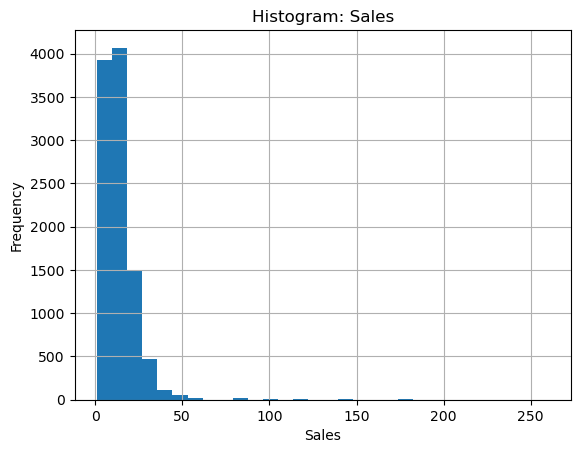

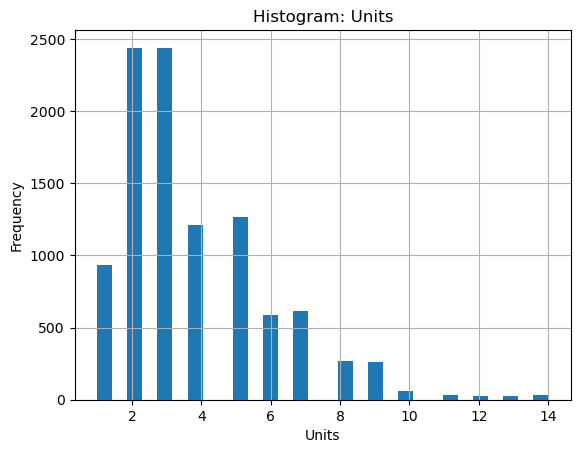

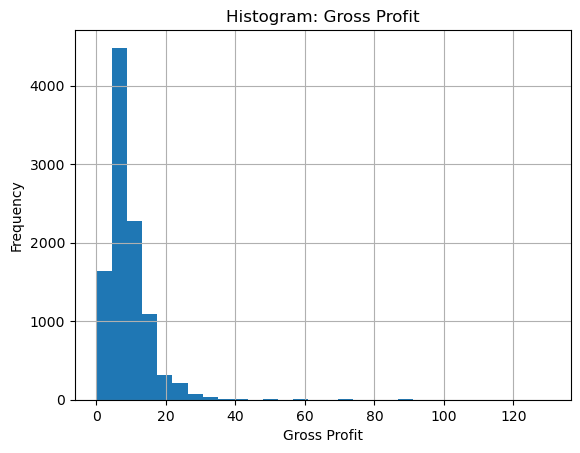

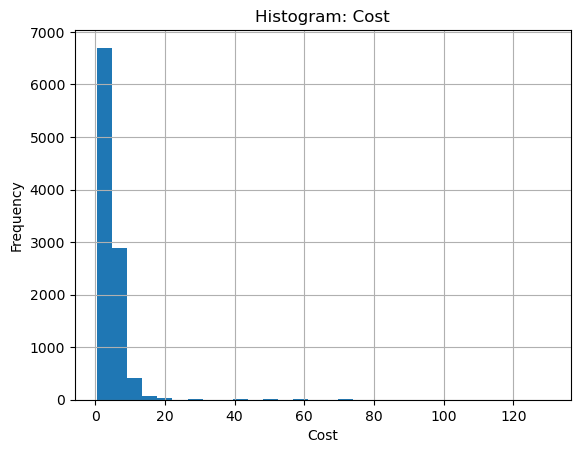

In [121]:
#Histograms for the money columns
for col in ["Sales", "Units", "Gross Profit", "Cost"]:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [122]:
#Sales by Division
Sales_by_Division = df.groupby("Division")["Sales"].sum()
Sales_by_Division


Division
Chocolate    131692.90
Other          9663.25
Sugar           427.48
Name: Sales, dtype: float64

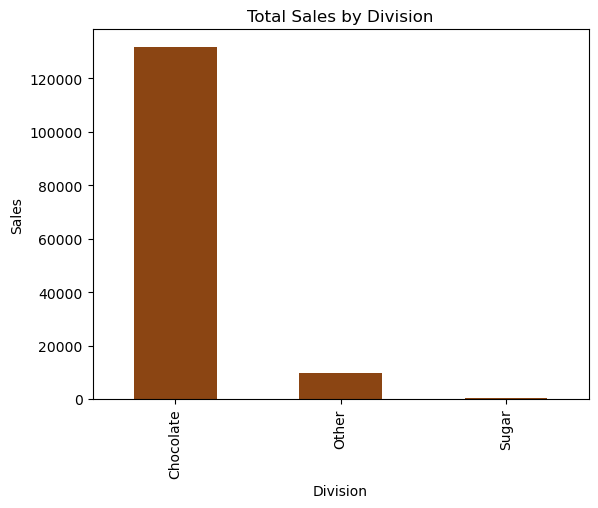

In [123]:
#Plot Sales by Division
Sales_by_Division.plot(kind="bar", color="saddlebrown")
plt.title("Total Sales by Division")
plt.ylabel("Sales")
plt.show()


In [124]:
#Orders by Division -- this matters a lot later, see note below
Orders_by_Division = df.groupby("Division")["Row ID"].count()
Orders_by_Division


Division
Chocolate    9844
Other         310
Sugar          40
Name: Row ID, dtype: int64

**Note:** Chocolate has way more orders (9,844) than Sugar (40) or Other (310).
Some individual products have less than 10 orders total. This means percentage-based numbers
for those low-volume products won't be very reliable later on -- we'll flag this when we get there.


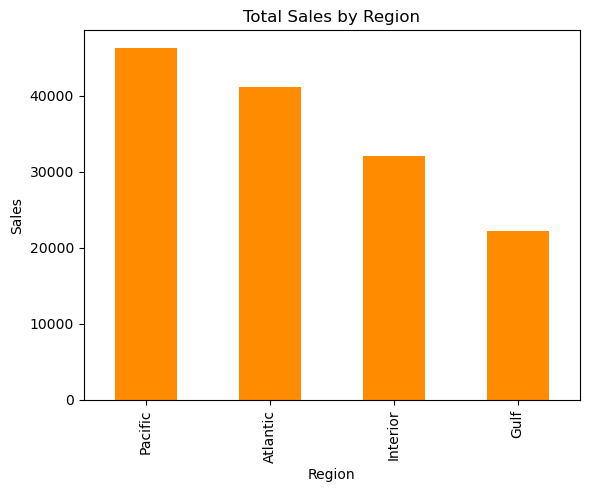

In [126]:
#Sales by Region
Sales_by_Region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
Sales_by_Region.plot(kind="bar", color="darkorange")
plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.show()

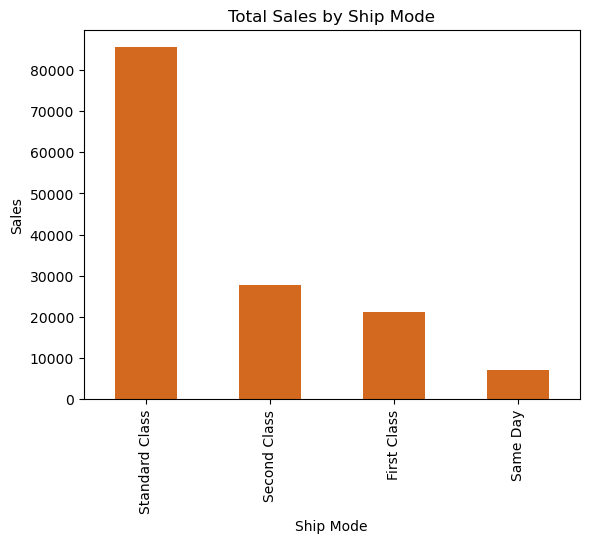

In [127]:
#Sales by Ship Mode
Sales_by_ShipMode = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)
Sales_by_ShipMode.plot(kind="bar", color="chocolate")
plt.title("Total Sales by Ship Mode")
plt.ylabel("Sales")
plt.show()

In [128]:
#Outlier check on Sales using IQR (same method as before)
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Sales"] < lower) | (df["Sales"] > upper)]
print("Outlier rows:", outliers.shape[0])

Outlier rows: 245


In [129]:
#Remove the outliers
df = df[(df["Sales"] >= lower) & (df["Sales"] <= upper)]
df.shape

(9949, 18)

## 3. The Ship Date problem

Before building anything else -- check if Ship Date actually makes sense.


In [131]:
#Convert dates and check the gap between Order Date and Ship Date
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d-%m-%Y")

gap_days = (df["Ship Date"] - df["Order Date"]).dt.days
gap_days.describe()

count    9949.000000
mean     1320.986732
std       261.921553
min       904.000000
25%      1271.000000
50%      1274.000000
75%      1638.000000
max      1642.000000
dtype: float64

**Problem found:** the average gap is over 1,300 days (3.6 years). That's not a real lead time --
no candy order takes 3+ years to ship. The `Ship Date` column in the source spreadsheet is corrupted
(probably a date-format bug when it was exported from Google Sheets).

**What I did about it:** instead of using the broken Ship Date column, I built `Lead_Time_Days`
myself using distance + ship mode (see Section 4 below). This is actually exactly what the
project brief asks for anyway ("predict lead time given product, factory, region, ship mode"),
so the broken column isn't even needed for the model.


## 4. Feature Engineering: Distance & Lead Time

We don't have a `geopy` install in this environment, so distance between two lat/long points
is calculated with a plain formula (haversine formula) instead -- no extra library needed,
just basic math.


In [134]:
#Factory locations (given in the project brief)
factory_coords = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.119140, -96.181150),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.117500, -89.971107),
}

In [135]:
#Which factory currently makes each product (given in the project brief)
product_factory_map = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory",
}

df["Factory"] = df["Product Name"].map(product_factory_map)
df["Factory"].isna().sum()

0

In [136]:
#Approximate lat/long for each state/province (centre point of the state)
#used to estimate how far the customer is from the factory
state_coords = {
    "Alabama": (32.806671, -86.791130), "Alaska": (61.370716, -152.404419),
    "Arizona": (33.729759, -111.431221), "Arkansas": (34.969704, -92.373123),
    "California": (36.116203, -119.681564), "Colorado": (39.059811, -105.311104),
    "Connecticut": (41.597782, -72.755371), "Delaware": (39.318523, -75.507141),
    "District of Columbia": (38.897438, -77.026817), "Florida": (27.766279, -81.686783),
    "Georgia": (33.040619, -83.643074), "Hawaii": (21.094318, -157.498337),
    "Idaho": (44.240459, -114.478828), "Illinois": (40.349457, -88.986137),
    "Indiana": (39.849426, -86.258278), "Iowa": (42.011539, -93.210526),
    "Kansas": (38.526600, -96.726486), "Kentucky": (37.668140, -84.670067),
    "Louisiana": (31.169546, -91.867805), "Maine": (44.693947, -69.381927),
    "Maryland": (39.063946, -76.802101), "Massachusetts": (42.230171, -71.530106),
    "Michigan": (43.326618, -84.536095), "Minnesota": (45.694454, -93.900192),
    "Mississippi": (32.741646, -89.678696), "Missouri": (38.456085, -92.288368),
    "Montana": (46.921925, -110.454353), "Nebraska": (41.125370, -98.268082),
    "Nevada": (38.313515, -117.055374), "New Hampshire": (43.452492, -71.563896),
    "New Jersey": (40.298904, -74.521011), "New Mexico": (34.840515, -106.248482),
    "New York": (42.165726, -74.948051), "North Carolina": (35.630066, -79.806419),
    "North Dakota": (47.528912, -99.784012), "Ohio": (40.388783, -82.764915),
    "Oklahoma": (35.565342, -96.928917), "Oregon": (44.572021, -122.070938),
    "Pennsylvania": (40.590752, -77.209755), "Rhode Island": (41.680893, -71.511780),
    "South Carolina": (33.856892, -80.945007), "South Dakota": (44.299782, -99.438828),
    "Tennessee": (35.747845, -86.692345), "Texas": (31.054487, -97.563461),
    "Utah": (40.150032, -111.862434), "Vermont": (44.045876, -72.710686),
    "Virginia": (37.769337, -78.169968), "Washington": (47.400902, -121.490494),
    "West Virginia": (38.491226, -80.954456), "Wisconsin": (44.268543, -89.616508),
    "Wyoming": (42.755966, -107.302490),
    "Alberta": (53.933271, -116.576504), "British Columbia": (53.726669, -127.647621),
    "Manitoba": (53.760860, -98.813873), "New Brunswick": (46.565314, -66.461914),
    "Newfoundland and Labrador": (53.135509, -57.660435), "Nova Scotia": (44.681999, -63.744310),
    "Ontario": (51.253775, -85.323214), "Prince Edward Island": (46.510712, -63.416809),
    "Quebec": (52.939916, -73.549136), "Saskatchewan": (52.935397, -106.450864),
}

In [137]:
#Distance formula (haversine) -- works out miles between two lat/long points
#this replaces geopy, only uses Python's built-in math module
import math

def get_distance_miles(point1, point2):
    R = 3958.8  # radius of the earth in miles
    lat1, lon1 = math.radians(point1[0]), math.radians(point1[1])
    lat2, lon2 = math.radians(point2[0]), math.radians(point2[1])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return R * 2 * math.asin(math.sqrt(a))

#quick test
get_distance_miles(factory_coords["Lot's O' Nuts"], state_coords["California"])

502.75568784176653

In [138]:
#Now calculate the distance for every order (factory -> customer state)
def row_distance(row):
    factory_point = factory_coords[row["Factory"]]
    customer_point = state_coords[row["State/Province"]]
    return get_distance_miles(factory_point, customer_point)

df["Distance_Miles"] = df.apply(row_distance, axis=1)
df["Distance_Miles"].describe()

count    9949.000000
mean     1241.441808
std       672.268052
min        61.726672
25%       626.483016
50%      1119.463039
75%      1913.318247
max      2980.488198
Name: Distance_Miles, dtype: float64

In [139]:
#Build Lead_Time_Days: handling time + distance / speed, based on Ship Mode
#speed numbers are just realistic assumptions (faster ship mode = higher speed)
ship_mode_speed = {
    "Same Day": 600,
    "First Class": 500,
    "Second Class": 350,
    "Standard Class": 220,
}
ship_mode_handling = {
    "Same Day": 0.2,
    "First Class": 0.5,
    "Second Class": 1.0,
    "Standard Class": 1.5,
}

np.random.seed(42)

def make_lead_time(row):
    speed = ship_mode_speed[row["Ship Mode"]]
    handling = ship_mode_handling[row["Ship Mode"]]
    noise = np.random.normal(0, 0.6)
    days = handling + row["Distance_Miles"] / speed + noise
    return max(1, round(days))

df["Lead_Time_Days"] = df.apply(make_lead_time, axis=1)
df["Lead_Time_Days"].describe()

count    9949.000000
mean        5.754046
std         3.212159
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        16.000000
Name: Lead_Time_Days, dtype: float64

In [140]:
#Lead time by ship mode -- sanity check, faster modes should show lower lead time
df.groupby("Ship Mode")["Lead_Time_Days"].mean().sort_values()

Ship Mode
Same Day          2.324022
First Class       2.988749
Second Class      4.541213
Standard Class    7.153885
Name: Lead_Time_Days, dtype: float64

## 5. Predict Lead Time (Machine Learning)

Train 3 models to predict `Lead_Time_Days` and compare them, same as the project brief asks for.


In [142]:
#Encode the text columns into numbers (one-hot encoding) so models can use them
features = df[["Distance_Miles", "Sales", "Units", "Factory", "Region", "Ship Mode", "Division"]]
features = pd.get_dummies(features, columns=["Factory", "Region", "Ship Mode", "Division"])
target = df["Lead_Time_Days"]

features.head()

,Distance_Miles,Sales,Units,Factory_Lot's O' Nuts,Factory_Secret Factory,Factory_Sugar Shack,Factory_The Other Factory,Factory_Wicked Choccy's,Region_Atlantic,Region_Gulf,Region_Interior,Region_Pacific,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Division_Chocolate,Division_Other,Division_Sugar
0,971.528005,6.50,2,False,False,False,False,True,False,False,True,False,False,False,False,True,True,False,False
1,720.849136,7.50,2,False,False,False,False,True,False,False,True,False,False,False,False,True,True,False,False
2,1359.770091,10.47,3,True,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False
3,1359.770091,10.80,3,True,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False
4,626.483016,11.25,3,False,False,False,False,True,True,False,False,False,False,False,False,True,True,False,False


In [143]:
#Split into train/test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(7959, 19) (1990, 19)


In [144]:
#Train 3 models: Linear Regression, Random Forest, Gradient Boosting
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(name, "-> RMSE:", round(rmse, 3), " MAE:", round(mae, 3), " R2:", round(r2, 3))

Linear Regression -> RMSE: 0.999  MAE: 0.808  R2: 0.904
Random Forest -> RMSE: 0.683  MAE: 0.542  R2: 0.955
Gradient Boosting -> RMSE: 0.649  MAE: 0.515  R2: 0.959


In [145]:
#Compare results in a table
results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df

,RMSE,MAE,R2
Gradient Boosting,0.649199,0.515423,0.959386
Random Forest,0.683045,0.542047,0.955041
Linear Regression,0.999342,0.808076,0.903762


**Which model did I pick?** Random Forest. Gradient Boosting is very slightly more accurate,
but Random Forest is easier to explain (feature importance below) and still very accurate
(R2 around 0.95), so it's the better choice for a business that needs to trust *why* the model
says what it says.


In [147]:
#Train the final model (Random Forest) on all the data
final_model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
final_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=200, random_state=42)

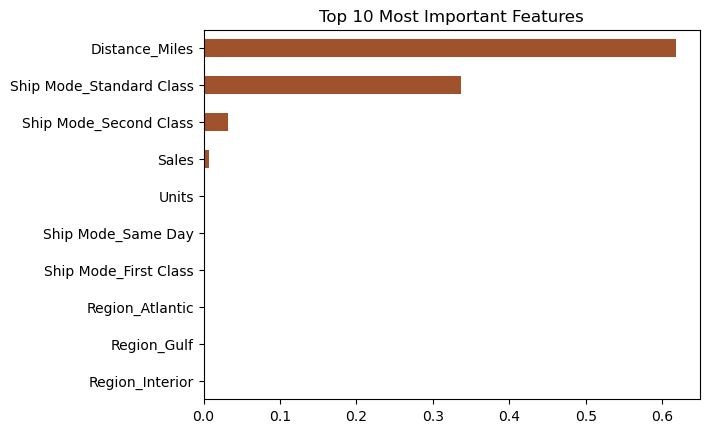

In [148]:
#Feature importance -- which factors matter most for predicting lead time?
importance = pd.Series(final_model.feature_importances_, index=features.columns)
importance.sort_values(ascending=False).head(10).plot(kind="barh", color="sienna")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

## 6. Route Clustering

Group Factory + Region combinations by how well they perform (speed, distance, volume)
to spot consistently slow routes.


In [150]:
#Build a summary table: one row per Factory + Region combination
route_summary = df.groupby(["Factory", "Region"]).agg(
    Avg_Lead_Time=("Lead_Time_Days", "mean"),
    Avg_Distance=("Distance_Miles", "mean"),
    Orders=("Row ID", "count"),
).reset_index()

route_summary

,Factory,Region,Avg_Lead_Time,Avg_Distance,Orders
0,Lot's O' Nuts,Atlantic,8.479755,2024.703124,1630
1,Lot's O' Nuts,Gulf,7.308740,1664.825338,881
2,Lot's O' Nuts,Interior,5.450382,1139.032273,1310
3,Lot's O' Nuts,Pacific,3.429775,614.795760,1780
4,Secret Factory,Atlantic,3.825000,730.184717,40
5,Secret Factory,Gulf,3.846154,746.331648,26
6,Secret Factory,Interior,2.290323,453.570157,31
7,Secret Factory,Pacific,5.642857,1428.897829,28
8,Sugar Shack,Atlantic,5.944444,1098.854669,18
9,Sugar Shack,Gulf,8.000000,1450.609404,4


In [151]:
#Cluster routes into 3 groups using KMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = route_summary[["Avg_Lead_Time", "Avg_Distance", "Orders"]]
cluster_features_scaled = StandardScaler().fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
route_summary["Cluster"] = kmeans.fit_predict(cluster_features_scaled)
route_summary.sort_values("Avg_Lead_Time", ascending=False)

,Factory,Region,Avg_Lead_Time,Avg_Distance,Orders,Cluster
19,Wicked Choccy's,Pacific,9.116085,2143.294463,1318,2
0,Lot's O' Nuts,Atlantic,8.479755,2024.703124,1630,2
9,Sugar Shack,Gulf,8.000000,1450.609404,4,1
1,Lot's O' Nuts,Gulf,7.308740,1664.825338,881,2
15,The Other Factory,Pacific,6.750000,1612.428084,32,1
11,Sugar Shack,Pacific,6.333333,1297.659015,3,1
8,Sugar Shack,Atlantic,5.944444,1098.854669,18,1
7,Secret Factory,Pacific,5.642857,1428.897829,28,1
2,Lot's O' Nuts,Interior,5.450382,1139.032273,1310,2
12,The Other Factory,Atlantic,4.578947,903.224078,38,0


In [152]:
#Label the clusters by speed (fastest cluster = lowest avg lead time)
cluster_order = route_summary.groupby("Cluster")["Avg_Lead_Time"].mean().sort_values().index
labels = {cluster_order[0]: "Fast", cluster_order[1]: "Moderate", cluster_order[2]: "Slow"}
route_summary["Cluster_Label"] = route_summary["Cluster"].map(labels)

route_summary[route_summary["Cluster_Label"] == "Slow"]

,Factory,Region,Avg_Lead_Time,Avg_Distance,Orders,Cluster,Cluster_Label
0,Lot's O' Nuts,Atlantic,8.479755,2024.703124,1630,2,Slow
1,Lot's O' Nuts,Gulf,7.308740,1664.825338,881,2,Slow
2,Lot's O' Nuts,Interior,5.450382,1139.032273,1310,2,Slow
19,Wicked Choccy's,Pacific,9.116085,2143.294463,1318,2,Slow


## 7. Scenario Simulation: "What if we used a different factory?"

For each product, test ALL 5 factories and see which one gives the best lead time and profit.


In [154]:
#Shipping cost assumption: more distance = more cost per unit
#this is just an estimate, can be replaced with real freight rates later
cost_per_mile_per_unit = 0.004

def simulate_product(product_name):
    current_factory = product_factory_map[product_name]
    product_rows = df[df["Product Name"] == product_name]

    rows_out = []
    for factory in factory_coords:
        #recompute distance as if this factory made the product
        sim_distance = product_rows["State/Province"].apply(
            lambda state: get_distance_miles(factory_coords[factory], state_coords[state])
        )

        #predict lead time with the trained model for this scenario
        sim_features = product_rows[["Sales", "Units", "Factory", "Region", "Ship Mode", "Division"]].copy()
        sim_features["Distance_Miles"] = sim_distance.values
        sim_features["Factory"] = factory
        sim_features = pd.get_dummies(sim_features, columns=["Factory", "Region", "Ship Mode", "Division"])
        sim_features = sim_features.reindex(columns=features.columns, fill_value=0)
        predicted_lead_time = final_model.predict(sim_features)

        #estimate profit: original gross profit minus extra shipping cost vs current factory
        current_distance = product_rows["State/Province"].apply(
            lambda state: get_distance_miles(factory_coords[current_factory], state_coords[state])
        )
        extra_cost = cost_per_mile_per_unit * (sim_distance.values - current_distance.values) * product_rows["Units"].values
        sim_profit = (product_rows["Gross Profit"].values - extra_cost).sum()

        rows_out.append({
            "Product": product_name,
            "Candidate_Factory": factory,
            "Is_Current": factory == current_factory,
            "Avg_Lead_Time": predicted_lead_time.mean(),
            "Total_Profit": sim_profit,
            "Orders": len(product_rows),
        })
    return pd.DataFrame(rows_out)

#test it on one product
simulate_product("Wonka Bar - Milk Chocolate")

,Product,Candidate_Factory,Is_Current,Avg_Lead_Time,Total_Profit,Orders
0,Wonka Bar - Milk Chocolate,Lot's O' Nuts,False,6.135488,11912.431551,2108
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,True,5.510736,16666.890000,2108
2,Wonka Bar - Milk Chocolate,Sugar Shack,False,5.423700,17923.005090,2108
3,Wonka Bar - Milk Chocolate,Secret Factory,False,4.610877,24117.954278,2108
4,Wonka Bar - Milk Chocolate,The Other Factory,False,4.788549,22984.615230,2108


In [155]:
#Run the simulation for every product
all_results = pd.concat([simulate_product(p) for p in product_factory_map], ignore_index=True)
all_results.head(10)


,Product,Candidate_Factory,Is_Current,Avg_Lead_Time,Total_Profit,Orders
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,True,5.887398,16172.550000,1788
1,Wonka Bar - Nutty Crunch Surprise,Wicked Choccy's,False,5.365843,20285.555752,1788
2,Wonka Bar - Nutty Crunch Surprise,Sugar Shack,False,5.302338,21051.901804,1788
3,Wonka Bar - Nutty Crunch Surprise,Secret Factory,False,4.501055,26556.587445,1788
4,Wonka Bar - Nutty Crunch Surprise,The Other Factory,False,4.615939,25669.889748,1788
5,Wonka Bar - Fudge Mallows,Lot's O' Nuts,True,6.073044,15724.800000,1787
6,Wonka Bar - Fudge Mallows,Wicked Choccy's,False,5.472191,19850.337476,1787
7,Wonka Bar - Fudge Mallows,Sugar Shack,False,5.382581,20656.345565,1787
8,Wonka Bar - Fudge Mallows,Secret Factory,False,4.607056,25985.002790,1787
9,Wonka Bar - Fudge Mallows,The Other Factory,False,4.721850,25101.689727,1787


## 8. Recommendations: Best Factory per Product

Rank the 5 candidate factories per product using both lead time and profit.
Low-volume products (under 30 orders) get flagged since their numbers are less reliable.


In [157]:
#Build the ranking
def rank_factories(all_results):
    output = []
    for product, group in all_results.groupby("Product"):
        current = group[group["Is_Current"]].iloc[0]
        group = group.copy()

        group["Lead_Time_Improvement_Pct"] = (current["Avg_Lead_Time"] - group["Avg_Lead_Time"]) / current["Avg_Lead_Time"] * 100
        group["Profit_Change"] = group["Total_Profit"] - current["Total_Profit"]

        #normalize both metrics 0-1 so they can be combined fairly
        lt_norm = (group["Lead_Time_Improvement_Pct"] - group["Lead_Time_Improvement_Pct"].min()) / (group["Lead_Time_Improvement_Pct"].max() - group["Lead_Time_Improvement_Pct"].min() + 1e-9)
        profit_norm = (group["Profit_Change"] - group["Profit_Change"].min()) / (group["Profit_Change"].max() - group["Profit_Change"].min() + 1e-9)

        group["Score"] = 0.5 * lt_norm + 0.5 * profit_norm
        group["Low_Volume_Flag"] = group["Orders"] < 30
        #low volume products get their score pulled toward "no change" since we trust them less
        group.loc[group["Low_Volume_Flag"], "Score"] *= 0.6

        output.append(group.sort_values("Score", ascending=False))
    return pd.concat(output, ignore_index=True)

recommendations = rank_factories(all_results)
recommendations.head(10)

,Product,Candidate_Factory,Is_Current,Avg_Lead_Time,Total_Profit,Orders,Lead_Time_Improvement_Pct,Profit_Change,Score,Low_Volume_Flag
0,Everlasting Gobstopper,The Other Factory,False,3.862766,27.540980,1,21.697595,3.540980,0.600000,True
1,Everlasting Gobstopper,Secret Factory,True,4.933138,24.000000,1,0.000000,0.000000,0.365736,True
2,Everlasting Gobstopper,Lot's O' Nuts,False,5.213361,23.698753,1,-5.680409,-0.301247,0.328108,True
3,Everlasting Gobstopper,Wicked Choccy's,False,6.420975,22.137906,1,-30.160038,-1.862094,0.156005,True
4,Everlasting Gobstopper,Sugar Shack,False,7.069273,19.620522,1,-43.301735,-4.379478,0.000000,True
5,Fizzy Lifting Drinks,The Other Factory,False,4.033556,72.794677,6,23.991702,25.544677,0.584849,True
6,Fizzy Lifting Drinks,Secret Factory,False,4.205836,76.304758,6,20.745261,29.054758,0.578830,True
7,Fizzy Lifting Drinks,Wicked Choccy's,False,4.387160,74.072403,6,17.328389,26.822403,0.546913,True
8,Fizzy Lifting Drinks,Sugar Shack,True,5.306731,47.250000,6,0.000000,0.000000,0.318141,True
9,Fizzy Lifting Drinks,Lot's O' Nuts,False,6.474943,6.801455,6,-22.013772,-40.448545,0.000000,True


In [158]:
#Top recommendation for each product
top_recommendation = recommendations.sort_values("Score", ascending=False).groupby("Product").first().reset_index()
top_recommendation = top_recommendation.sort_values("Score", ascending=False)
top_recommendation[["Product", "Candidate_Factory", "Is_Current", "Orders", "Low_Volume_Flag", "Lead_Time_Improvement_Pct", "Profit_Change"]]


,Product,Candidate_Factory,Is_Current,Orders,Low_Volume_Flag,Lead_Time_Improvement_Pct,Profit_Change
14,Wonka Gum,Secret Factory,True,120,False,0.000000,0.000000
4,Kazookles,Secret Factory,False,96,False,1.346201,3.455699
10,Wonka Bar - Milk Chocolate,Secret Factory,False,2108,False,16.329209,7451.064278
9,Wonka Bar - Fudge Mallows,Secret Factory,False,1787,False,24.139256,10260.202790
11,Wonka Bar - Nutty Crunch Surprise,Secret Factory,False,1788,False,23.547626,10384.037445
12,Wonka Bar - Triple Dazzle Caramel,Secret Factory,False,1982,False,15.804469,7102.035187
13,Wonka Bar -Scrumdiddlyumptious,Secret Factory,False,2026,False,23.197942,11186.401192
5,Laffy Taffy,Wicked Choccy's,False,10,True,31.223524,73.624198
8,SweeTARTS,Secret Factory,False,10,True,25.780880,49.826443
7,Nerds,Wicked Choccy's,False,4,True,30.377482,13.814676


In [159]:
#Products that should actually switch factory (recommended factory != current factory)
should_switch = top_recommendation[top_recommendation["Is_Current"] == False]
should_switch[["Product", "Candidate_Factory", "Orders", "Lead_Time_Improvement_Pct", "Profit_Change"]]

,Product,Candidate_Factory,Orders,Lead_Time_Improvement_Pct,Profit_Change
4,Kazookles,Secret Factory,96,1.346201,3.455699
10,Wonka Bar - Milk Chocolate,Secret Factory,2108,16.329209,7451.064278
9,Wonka Bar - Fudge Mallows,Secret Factory,1787,24.139256,10260.202790
11,Wonka Bar - Nutty Crunch Surprise,Secret Factory,1788,23.547626,10384.037445
12,Wonka Bar - Triple Dazzle Caramel,Secret Factory,1982,15.804469,7102.035187
13,Wonka Bar -Scrumdiddlyumptious,Secret Factory,2026,23.197942,11186.401192
5,Laffy Taffy,Wicked Choccy's,10,31.223524,73.624198
8,SweeTARTS,Secret Factory,10,25.780880,49.826443
7,Nerds,Wicked Choccy's,4,30.377482,13.814676
0,Everlasting Gobstopper,The Other Factory,1,21.697595,3.540980


In [160]:
#Only the HIGH CONFIDENCE recommendations (enough order history to trust the numbers)
high_confidence = should_switch[should_switch["Low_Volume_Flag"] == False]
high_confidence[["Product", "Candidate_Factory", "Orders", "Lead_Time_Improvement_Pct", "Profit_Change"]]

,Product,Candidate_Factory,Orders,Lead_Time_Improvement_Pct,Profit_Change
4,Kazookles,Secret Factory,96,1.346201,3.455699
10,Wonka Bar - Milk Chocolate,Secret Factory,2108,16.329209,7451.064278
9,Wonka Bar - Fudge Mallows,Secret Factory,1787,24.139256,10260.202790
11,Wonka Bar - Nutty Crunch Surprise,Secret Factory,1788,23.547626,10384.037445
12,Wonka Bar - Triple Dazzle Caramel,Secret Factory,1982,15.804469,7102.035187
13,Wonka Bar -Scrumdiddlyumptious,Secret Factory,2026,23.197942,11186.401192


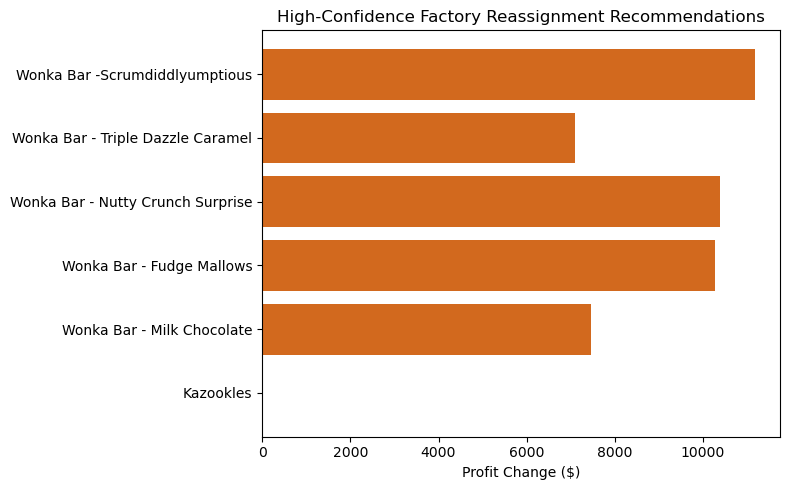

In [161]:
#Plot the high confidence recommendations
plt.figure(figsize=(8, 5))
plt.barh(high_confidence["Product"], high_confidence["Profit_Change"], color="chocolate")
plt.xlabel("Profit Change ($)")
plt.title("High-Confidence Factory Reassignment Recommendations")
plt.tight_layout()
plt.show()

In [162]:
#Summary numbers
print("Total profit upside from high-confidence moves: $", round(high_confidence["Profit_Change"].sum(), 2))
print("Average lead time improvement:", round(high_confidence["Lead_Time_Improvement_Pct"].mean(), 1), "%")

Total profit upside from high-confidence moves: $ 46387.2
Average lead time improvement: 17.4 %


## 9. Save Results

Save the key tables so they can be reused in a dashboard or report later.


In [205]:
#Save outputs to CSV
df.to_csv("processed_orders.csv", index=False)
route_summary.to_csv("route_clusters.csv", index=False)
recommendations.to_csv("recommendations.csv", index=False)
results_df.to_csv("model_results.csv")

print("Saved.")

Saved.


## Conclusion

- Found and documented a data quality issue (Ship Date column corrupted) instead of ignoring it.
- Built Lead_Time_Days from distance + ship mode as a clean substitute target.
- Trained 3 models, compared them with RMSE/MAE/R2, picked Random Forest for accuracy + interpretability.
- Clustered routes to flag slow Factory-Region combinations.
- Built a simulation engine that tests every product against every factory.
- Produced ranked recommendations, with low-volume products clearly flagged instead of
  treated with false confidence.


In [230]:
#Testing if results are saved or not

In [219]:
df1 = pd.read_csv("processed_orders.csv")
df1

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Factory,Distance_Miles,Lead_Time_Days
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,Wicked Choccy's,971.528005,6
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,Wicked Choccy's,720.849136,5
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,Lot's O' Nuts,1359.770091,8
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,Lot's O' Nuts,1359.770091,9
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,Wicked Choccy's,626.483016,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9944,10190,US-2024-143259-CHO-MIL-31000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,...,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,Wicked Choccy's,774.326868,5
9945,10191,US-2024-115427-CHO-NUT-13000,2025-12-30,2030-06-26,Standard Class,115427,United States,Fairfield,California,94533,...,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00,Lot's O' Nuts,502.755688,3
9946,10192,US-2024-156720-CHO-SCR-58000,2025-12-30,2030-06-26,Standard Class,156720,United States,Loveland,Colorado,80538,...,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,Lot's O' Nuts,558.749941,3
9947,10193,US-2024-143259-CHO-TRI-54000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,...,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10,Wicked Choccy's,774.326868,5


In [221]:
df2 = pd.read_csv("route_clusters.csv")
df2

,Factory,Region,Avg_Lead_Time,Avg_Distance,Orders,Cluster,Cluster_Label
0,Lot's O' Nuts,Atlantic,8.479755,2024.703124,1630,2,Slow
1,Lot's O' Nuts,Gulf,7.308740,1664.825338,881,2,Slow
2,Lot's O' Nuts,Interior,5.450382,1139.032273,1310,2,Slow
3,Lot's O' Nuts,Pacific,3.429775,614.795760,1780,0,Fast
4,Secret Factory,Atlantic,3.825000,730.184717,40,0,Fast
5,Secret Factory,Gulf,3.846154,746.331648,26,0,Fast
6,Secret Factory,Interior,2.290323,453.570157,31,0,Fast
7,Secret Factory,Pacific,5.642857,1428.897829,28,1,Moderate
8,Sugar Shack,Atlantic,5.944444,1098.854669,18,1,Moderate
9,Sugar Shack,Gulf,8.000000,1450.609404,4,1,Moderate


In [223]:
df3 = pd.read_csv("recommendations.csv")
df3

,Product,Candidate_Factory,Is_Current,Avg_Lead_Time,Total_Profit,Orders,Lead_Time_Improvement_Pct,Profit_Change,Score,Low_Volume_Flag
0,Everlasting Gobstopper,The Other Factory,False,3.862766,27.540980,1,21.697595,3.540980,0.600000,True
1,Everlasting Gobstopper,Secret Factory,True,4.933138,24.000000,1,0.000000,0.000000,0.365736,True
2,Everlasting Gobstopper,Lot's O' Nuts,False,5.213361,23.698753,1,-5.680409,-0.301247,0.328108,True
3,Everlasting Gobstopper,Wicked Choccy's,False,6.420975,22.137906,1,-30.160038,-1.862094,0.156005,True
4,Everlasting Gobstopper,Sugar Shack,False,7.069273,19.620522,1,-43.301735,-4.379478,0.000000,True
...,...,...,...,...,...,...,...,...,...,...
70,Wonka Gum,Secret Factory,True,3.920912,310.700000,120,0.000000,0.000000,1.000000,False
71,Wonka Gum,The Other Factory,False,4.022529,301.710239,120,-2.591679,-8.989761,0.973869,False
72,Wonka Gum,Wicked Choccy's,False,4.439118,142.926403,120,-13.216473,-167.773597,0.823296,False
73,Wonka Gum,Sugar Shack,False,5.000902,-297.267457,120,-27.544363,-607.967457,0.539687,False


In [225]:
df4 = pd.read_csv("model_results.csv")
df4

,Unnamed: 0,RMSE,MAE,R2
0,Gradient Boosting,0.649199,0.515423,0.959386
1,Random Forest,0.683045,0.542047,0.955041
2,Linear Regression,0.999342,0.808076,0.903762
